## Settings & imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)


ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]
FIGURES_PATH = config["figures_path"]['all']

In [3]:
DATASETS = ['Konstytucja', 'corroded', 'Merkuriusz', 'Kopernik']

## Loading the data

In [4]:
dfs = []
labels = []

for DATASET in DATASETS:
    
    PREDICTION_PATH = config["prediction_path"][DATASET]
    PREPROCESSED_DATA_PATH = config["preprocessed_data_path"][DATASET]
    
    df = load_prediction(PREDICTION_PATH, ELEMENTS_TO_KEEP_NO_FE)
    y_true = load_target_data(PREPROCESSED_DATA_PATH, ['name'], header=0)['Sample_id']

    dfs.append(df)
    labels.append(DATASET + '_' + y_true)

df = pd.concat(dfs)
y_true = pd.concat(labels)
y_true = y_true.apply(lambda x: x.split('_')[0])

### Converting to np.array

In [5]:
X = np.array(df.values)

### Heatmap

In [6]:
#visulise_clustering_on_heatmap(X, y_true.values, ELEMENTS_TO_KEEP_NO_FE, show_classes_names=False, figures_path='../figures/')

### PCA - all points

In [7]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

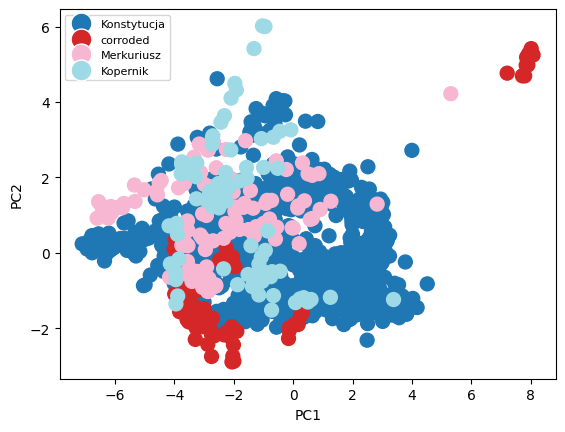

In [8]:
visualise_pca(X_pca, y_true, figures_path=FIGURES_PATH + 'PCA.png')

In [9]:
#visualise_means_pca(X, y_true, elements_to_keep=ELEMENTS_TO_KEEP_NO_FE, figures_path=FIGURES_PATH + 'means.png')

### tSNE - all points

In [10]:
from sklearn.manifold import TSNE

n_components = 2
tsne = TSNE(n_components=n_components, random_state=42)
X_tsne = tsne.fit_transform(X)

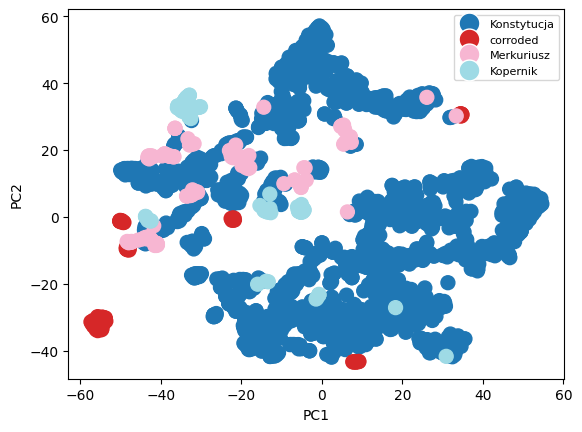

In [11]:
visualise_pca(X_tsne, y_true, figures_path=FIGURES_PATH + 'tsne', method_name='tsne')